In [42]:
import numpy as np
from scipy import signal
import tensorflow as tf
from tensorflow.keras import layers, Model, initializers, Sequential
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [43]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [44]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [45]:
def select_cpr_mode(paramCPR_, CPR_Mode, Ts, M):
    paramCPR = paramCPR_
    paramCPR.Ts = Ts
    paramCPR.M  = M
    paramCPR.returnPhases = True

    if CPR_Mode.lower() == "bps":
        paramCPR.alg = "bps"
        if M == 16:
            paramCPR.N = 25
            paramCPR.B = 64
        elif M == 32:
            paramCPR.N = 31
            paramCPR.B = 128
        elif M == 64:
            #paramCPR.N = 81
            paramCPR.N = 101
            paramCPR.B = 2048
            #paramCPR.B = 1024
        elif M == 256:
            paramCPR.N = 81
            paramCPR.B = 512

    elif CPR_Mode.lower() == "ddpll":
        paramCPR.alg = "ddpll"
        if M == 16:
            # recommended DDPLL parameters
            paramCPR.tau1 = 1/(2*np.pi*10e3)
            paramCPR.tau2 = 1/(2*np.pi*10e3)
            paramCPR.Kv   = 0.1
        elif M == 32:
            paramCPR.tau1 = 1/(2*np.pi*20e3)
            paramCPR.tau2 = 1/(2*np.pi*20e3)
            paramCPR.Kv   = 0.1
            
        elif M == 64:
            #paramCPR.tau1 = 1/(2*np.pi*30e3)
            #paramCPR.tau2 = 1/(2*np.pi*30e3)
            #paramCPR.Kv   = 0.15
            paramCPR.Kv = 0.07
            paramCPR.tau1 = 1/(2*np.pi*5e6)
            paramCPR.tau2 = 1/(2*np.pi*5e6)
        elif M == 256:
            paramCPR.tau1 = 1/(2*np.pi*40e3)
            paramCPR.tau2 = 1/(2*np.pi*40e3)
            paramCPR.Kv   = 0.12  # faster tracking needed
          
    else:
        raise ValueError("CPR_Mode must be 'bps' or 'ddpll'")

    return paramCPR

In [46]:
def select_equalizer_mode(M, Data_Aided, paramEq_):
    """
    Selects the equalizer algorithm and step sizes 
    based on M, Data_Aided flag, and chosen mode.
    """
    paramEq = paramEq_
    if Data_Aided:
        if M == 4:
            # For QPSK
            paramEq.alg = ['cma', 'cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            # For 16-QAM
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [5e-3, 5e-4]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [8e-4, 4e-4]
            paramEq.mu  = [8e-4, 3e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
            #paramEq.alg = ['da-rde', 'cma']
            #paramEq.mu = [3e-4, 5e-5]
            #paramEq.numIter = 4
            #paramEq.nTaps = 85
        elif M == 256:
            paramEq.alg = ['da-rde', 'da-rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 180
            
            
    else:  # Blind mode
        if M == 4:
            paramEq.alg = ['cma','cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [1e-3, 1e-3]
            paramEq.numIter = 5
            paramEq.nTaps = 55
        elif M == 256:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [5e-4, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
   
            
    return paramEq

In [47]:
def perf_calc(symbTx, y_CPR_1, d_, M, paramSymb):
    """Performance Metric Exploration for Single Polarization"""
    d = d_
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    
    # Remove phase ambiguity for all M (optional: for QAM)
    if M in [4, 16, 32, 64, 128]:
        d = symbTx  # or processed reference symbols

    # Compute metrics
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

    return BER[0], SER[0], SNR[0], EVM[0], Qfactor

In [48]:
# ----------------------------------------------
# Simulation of the Optical System (parametric version)
# -----------------------------------------------

def simulate_optical_system(
    symbTx,
    no_symbols_sent,
    M,
    PA_enable=True,
    Data_Aided=True,
    SpS=16,
    SpSout=2,
    Fs=None,
    mzmScale=0.5,
    Vpi=2,
    BLPF_enable=True,
    PA_BO_dB=3,
    PA_p=2.0,
    PA_f3dB=18.5e9,
    P_launch_dBm=0,
    Rs = 32e9,                
    rollOff = 0.01,           
    nFilterTaps = 1024,       
    laserLinewidth = 100e3, 
    FO  = -128e6,
    CPR_Mode = "bps",
    pulse_type="rrc",
    ch_Ltotal_km=80,
    ch_Lspan_km=80,
    ch_alpha_dB_per_km=0.2,
    ch_D_ps_nm_km=16,
    ch_gamma=1.3,
    ch_Fc=193.1e12,
    ch_hz_km=0.5,
    ch_prgsBar=True,
    ch_amp="edfa",
    ch_NF_dB=4.5,
    lo_P_dBm=2,
    lo_linewidth_hz=100e3,
    lo_RIN_var=0,
    lo_freq_shift_base_hz=0,
    pn_tx_seed=123,
    lo_rx_seed=789,
    pd_seed=1011,
    pd_ideal=True,
    edc_Fs=None,
    pa_order=3,
    ):   

    # (derived) params
    if Fs is None:
        Fs = Rs * SpS
    # 3) UpSampling and FIR Parameters
    paramPulse = parameters()
    paramPulse.pulseType = pulse_type
    paramPulse.nFilterTaps = nFilterTaps
    paramPulse.rollOff = rollOff
    paramPulse.SpS = SpS

    # 4) IQM Parameters
    paramIQM = parameters()
    paramIQM.Vpi = Vpi
    paramIQM.VbI = -Vpi
    paramIQM.VbQ = -Vpi
    paramIQM.Vphi = Vpi/2

    # 5) Optical Carrier / LO field (Ein)
    sigTx_length = no_symbols_sent * SpS
    if laserLinewidth and laserLinewidth > 0:
        phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=pn_tx_seed)
        sigLO = np.exp(1j * phi_pn)
    else:
        sigLO = np.ones_like(sigTx_length, dtype=complex)


    # -----------------------------------------------
    # Channel Parameters
    #------------------------------------------------

    # 1) Optical Channel Parameters
    paramCh = parameters()
    paramCh.Ltotal = ch_Ltotal_km
    paramCh.Lspan = ch_Lspan_km
    paramCh.alpha = ch_alpha_dB_per_km
    paramCh.D = ch_D_ps_nm_km
    paramCh.gamma = ch_gamma
    paramCh.Fc = ch_Fc
    paramCh.hz = ch_hz_km
    paramCh.prgsBar = ch_prgsBar
    paramCh.Fs = Fs
    paramCh.amp = ch_amp
    paramCh.NF = ch_NF_dB
    #paramCh.seed = 456


    # -----------------------------------------------
    # Receiver Parameters
    #------------------------------------------------

    # 1) local oscillator (LO) parameters:

    paramLO = parameters()
    paramLO.P = lo_P_dBm
    paramLO.lw = lo_linewidth_hz
    paramLO.RIN_var = lo_RIN_var
    paramLO.Fs = Fs
    paramLO.seed = lo_rx_seed
    paramLO.freqShift = lo_freq_shift_base_hz + FO

    # 2) Front-End Parameters and photodiode paramters

    # Frontend parameters
    paramFE = parameters()
    paramFE.Fs = Fs

    # Photodiodes parameters
    paramPD = parameters()
    paramPD.B = Rs
    paramPD.Fs = Fs
    paramPD.ideal = pd_ideal
    paramPD.seed = pd_seed

    # 3) Pulseshaping in the reciever using rrc filter
    paramRxPulse = parameters()
    paramRxPulse.SpS = SpS
    paramRxPulse.nFilterTaps = nFilterTaps
    paramRxPulse.rollOff = rollOff
    paramRxPulse.pulseType = pulse_type

    # 4) Decimation Parameters
    paramDec = parameters()
    paramDec.SpSin  = SpS
    paramDec.SpSout = SpSout

    # 5) Chromatic Dispersion Parameters
    paramEDC = parameters()
    paramEDC.L = paramCh.Ltotal
    paramEDC.D = paramCh.D
    paramEDC.Fc = paramCh.Fc
    paramEDC.Rs = Rs
    paramEDC.Fs = 2 * Rs if edc_Fs is None else edc_Fs

    # 6) Adaptive Equalization Parameters
    paramEq = parameters()
    paramEq.nTaps = 35
    paramEq.SpS = paramDec.SpSout
    paramEq.numIter = 2
    paramEq.storeCoeff = False
    paramEq.M = M
    paramEq.shapingFactor = 0
    paramEq.constType = "qam"
    paramEq.prgsBar = False

    # 7) Data-Aided or Blind Reciever Equalization
    # Can be set here or not
    #Data_Aided = True

    # 8) Carrier and Phase recovery parameters using bps
    paramCPR = parameters()
    paramCPR.alg = 'bps'
    paramCPR.M   = M
    paramCPR.constType ="qam"
    paramCPR.shapingFactor = 0
    paramCPR.N   = 25
    paramCPR.B   = 64
    paramCPR.returnPhases = True
    paramCPR.Ts = 1/Rs




    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 3) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 4) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable=BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=pa_order,
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 5) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 6) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver for single-polarization
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pulse shaping
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD)
    d = pnorm(symbRxCD)

    if M==256 and Data_Aided:
        paramEq.L = [int(0.5*d.shape[0]), int(0.5*d.shape[0])]
    else:
        paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
   
    #paramEq.L         = [int(0.8 * d.shape[0])]    # or d.shape[0] - 20k
    # ------------------------------------------------
    # 5) EQUALIZATION (via DSP SWITCH)
    # ------------------------------------------------
    paramEq = select_equalizer_mode(M, Data_Aided, paramEq)

    if Data_Aided:
        print(" adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, d)
    else:
        print("no adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, None)

    #y_EQ, h_rls = rls_single_pol(x, d, L=21, lam=0.995, delta=1e3)

    # ------------------------------------------------
    # 6) Frequency Offset Compensation
    # ------------------------------------------------
    Ts = 1 / Rs
    paramCPR = select_cpr_mode(paramCPR, CPR_Mode, Ts, M)
    if CPR_Mode == "ddpll":
        print("no bps")
        
        y_EQ_2D = y_EQ.reshape(-1,1) if y_EQ.ndim == 1 else y_EQ
        
        symbTx_2D = symbTx.reshape(-1,1)
        y_CPR_1, phaseEst = cpr(y_EQ_2D, param=paramCPR, symbTx=symbTx_2D)
        y_CPR_1= y_CPR_1.flatten()
    else:
        print("yes bps")
        y_CPR_1, phaseEst = cpr(y_EQ, paramCPR)

    return y_CPR_1, d, phaseEst


In [49]:
def intialise_paramSymb(M, nBits, seed=444):
    # Symbol generation    
    paramSymb = parameters()
    paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
    paramSymb.M = M
    paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
    paramSymb.dist = "uniform"                     # uniform symbol probabilities
    paramSymb.seed = 444
    paramSymb.shapingFactor = 0

    constSymb = grayMapping(paramSymb.M, paramSymb.constType)
    if paramSymb.dist == "uniform":
        px = np.ones(paramSymb.M) / paramSymb.M
    elif paramSymb.probDist == "maxwell-boltzmann":
        px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
        px = px / np.sum(px)
    else:
        raise ValueError("Invalid probability distribution.")
    paramSymb.px = px
    return paramSymb

# System First Trial - No DPD


In [50]:
M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)


In [51]:
symbTx = symbolSource(paramSymb)


y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, PA_enable=True, Data_Aided=True, SpSout=SpSout)


perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


# discard = 5000
# # plot constellations
# pconst(y_CPR_1[discard:-discard])

# # plotting eye diagrams of sigTx
# eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, SpSout, plotlabel='signal at Rx REAL', ptype='fancy')
# eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, SpSout, plotlabel='signal at Rx IMAGNIARY', ptype='fancy')


  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.040935.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.035054.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.034972.
rde - training stage #1


 adied


rde MSE = 0.023344.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 366.545 kHz


 SER: 5.889e-04,  
 BER: 1.472e-04   
 SNR: 19.621 dB
 EVM: 1.095 %
 Qfactor: 5.587,  


(np.float64(0.00014722222222222223),
 np.float64(0.0005888888888888889),
 np.float64(19.620869071654614),
 np.float64(0.010951919747258218),
 np.float64(5.587252832059657))

# System Benchmark (No DPD)

In [52]:
# results = []

# # modulation orders to test
# mod_orders = [16,64,256]

# # DA and CPR modes
# modes_DataAided = [True, False]
# modes_CPR = [ "bps","ddpll"]

# for M_test in mod_orders:
#     M = M_test
#     paramSymb = intialise_paramSymb(M, nBits) # need to update it everytime M changes
#     for da in modes_DataAided:
#         for cpr_mode in modes_CPR:
#             print("\n===================================================")
#             print(f" Running:  M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}")
#             print("===================================================\n")
        
#             # fresh symbol stream each run
#             symbTx = symbolSource(paramSymb)
            
#             # run sys
#             y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, 
#                                                            Data_Aided=da, 
#                                                            SpSout=SpSout,
#                                                            CPR_Mode=cpr_mode)

#             discard = 5000

#             # optional: plot constellations
#             pconst(y_CPR_1[discard:-discard])

#             # plotting eye diagrams
#             eyediagram(y_CPR_1.real[discard:-discard],
#                         y_CPR_1.real.size-2*discard,
#                         SpSout,
#                         plotlabel=f'signal at Rx REAL, M={M}', ptype='fancy')
#             eyediagram(y_CPR_1.imag[discard:-discard],
#                         y_CPR_1.imag.size-2*discard,
#                         SpSout,
#                         plotlabel=f'signal at Rx IMAGINARY, M={M}', ptype='fancy')


#             # performance
#             BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


#             results.append({
#                 "Modulation": M,
#                 "Data_Aided": da,
#                 "CPR": cpr_mode,
#                 "BER": BER,
#                 "SER": SER,
#                 "SNR": SNR,
#                 "EVM": EVM,
#                 "Qfactor": Q
#             })


In [53]:
# print("\n==================== SUMMARY TABLE ====================\n")
# for r in results:
#     print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
#           f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
#           f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")

# DPD


In [54]:
import numpy as np

# ------------------------------------------------------------
# Basic helpers
# ------------------------------------------------------------

def c1d(x):
    return np.asarray(x).reshape(-1).astype(np.complex128)


def align_iq(ref, rx):
    """
    Integer-lag alignment using complex correlation
    """
    ref = c1d(ref)
    rx = c1d(rx)

    ref0 = ref - np.mean(ref)
    rx0 = rx - np.mean(rx)

    corr = np.correlate(rx0, ref0, mode="full")
    lag = int(np.argmax(np.abs(corr)) - (len(ref0) - 1))

    if lag >= 0:
        rx_aligned = rx[lag:]
        ref_aligned = ref[:len(rx_aligned)]
    else:
        ref_aligned = ref[-lag:]
        rx_aligned = rx[:len(ref_aligned)]

    L = min(len(ref_aligned), len(rx_aligned))
    return ref_aligned[:L], rx_aligned[:L], lag


def phase_align(ref, rx):
    """
    Remove residual common phase rotation
    """
    ref = c1d(ref)
    rx = c1d(rx)

    phi = np.angle(np.vdot(rx, ref))
    rx_rot = rx * np.exp(-1j * phi)
    return rx_rot, phi


def power_align(ref, rx):
    """
    Match rx power to ref power
    """
    ref = c1d(ref)
    rx = c1d(rx)

    scale = np.sqrt(
        (np.mean(np.abs(ref) ** 2) + 1e-12) /
        (np.mean(np.abs(rx) ** 2) + 1e-12)
    )
    return rx * scale, scale


def clip_match(x, ref, clip_sigma=4.5):
    """
    Power normalisation + clipping
    """
    x = c1d(x)
    ref = c1d(ref)

    x = x - np.mean(x)
    ref0 = ref - np.mean(ref)

    px = np.mean(np.abs(x) ** 2) + 1e-12
    pr = np.mean(np.abs(ref0) ** 2) + 1e-12
    x = x * np.sqrt(pr / px)

    xr = np.real(x).copy()
    xi = np.imag(x).copy()

    mu_r, sd_r = np.mean(xr), np.std(xr) + 1e-12
    mu_i, sd_i = np.mean(xi), np.std(xi) + 1e-12

    xr = np.clip(xr, mu_r - clip_sigma * sd_r, mu_r + clip_sigma * sd_r)
    xi = np.clip(xi, mu_i - clip_sigma * sd_i, mu_i + clip_sigma * sd_i)

    return xr + 1j * xi

In [55]:
# ------------------------------------------------------------
# Memory Polynomial model
# z(n) = sum a_{p,m} x(n-m)|x(n-m)|^(p-1)
# ------------------------------------------------------------

def build_mp_features(x, memory=9, orders=(1, 3, 5, 7)):
    x = c1d(x)
    N = len(x)
    start = memory - 1
    end = N

    cols = []
    for p in orders:
        base = x * (np.abs(x) ** (p - 1))
        for m in range(memory):
            cols.append(base[start - m : end - m])

    Phi = np.column_stack(cols)
    return Phi, start, end


def fit_mp(rx, target, memory=9, orders=(1, 3, 5, 7), ridge=1e-4):
    rx = c1d(rx)
    target = c1d(target)

    Phi, start, end = build_mp_features(rx, memory=memory, orders=orders)
    d = target[start:end]

    A = Phi.conj().T @ Phi + ridge * np.eye(Phi.shape[1], dtype=np.complex128)
    w = np.linalg.solve(A, Phi.conj().T @ d)

    return {
        "memory": memory,
        "orders": tuple(orders),
        "ridge": ridge,
        "start": start,
        "end": end,
        "w": w,
    }


def apply_mp(x, model):
    x = c1d(x)

    Phi, start, end = build_mp_features(
        x,
        memory=model["memory"],
        orders=model["orders"]
    )

    y = x.copy()
    y[start:end] = Phi @ model["w"]
    return y

In [68]:
# ------------------------------------------------------------
# ILA training with MP-DPD
# ------------------------------------------------------------

def train_MP_DPD(
    M,
    nBits=400000,
    iteration_cnt=6,
    memory=9,
    orders=(1, 3, 5, 7),
    ridge=1e-4,
    clip_sigma=4.5,
    alpha=1.0,
    guard=2000,
    seed=333,
    verbose=True,
    **kwargs
):
    """
    Train MP-DPD using ILA on top of your existing optical system.
    kwargs are passed directly into simulate_optical_system(...)

    alpha:
        update damping factor for stable ILA
        x_new = (1-alpha)*x_ref + alpha*MP(x_ref)
    """

    paramSymb = intialise_paramSymb(M, nBits, seed=seed)
    symbTx = symbolSource(paramSymb)
    x_ref = c1d(symbTx)
    reference = symbTx # new

    x_pd = x_ref.copy()
    best = None
    hist = []

    print("===================================================")
    print("Training MP-DPD")
    print("===================================================")
    print(f"M           = {M}")
    print(f"nBits       = {nBits}")
    print(f"iteration   = {iteration_cnt}")
    print(f"memory      = {memory}")
    print(f"orders      = {orders}")
    print(f"ridge       = {ridge}")
    print(f"clip_sigma  = {clip_sigma}")
    print(f"alpha       = {alpha}")
    print("===================================================\n")

    for iteration in range(iteration_cnt):
        print(f"====== Iteration {iteration + 1} ======")

        # current predistorted signal through real system
        y_cur, d_cur, phaseEst_cur = simulate_optical_system(
            x_pd,
            len(x_pd),
            M,
            **kwargs
        )

        BER_cur, SER_cur, SNR_cur, EVM_cur, Q_cur = perf_calc(
            x_ref, y_cur, d_cur, M, paramSymb
        )

        # align training pairs
        tx_target, rx_train, lag = align_iq(x_ref, y_cur)
        rx_train, phi = phase_align(tx_target, rx_train)
        rx_train, scale = power_align(tx_target, rx_train)

        # remove edges if enough samples
        if len(tx_target) > 2 * guard:
            tx_target_fit = tx_target[guard:-guard]
            rx_train_fit = rx_train[guard:-guard]
        else:
            tx_target_fit = tx_target
            rx_train_fit = rx_train

        if verbose:
            print(
                f"alignment lag = {lag}, "
                f"phase = {phi:.6f} rad, "
                f"scale = {scale:.6f}, "
                f"fit_len = {len(tx_target_fit)}"
            )

        # fit post-inverse MP
        mp_model = fit_mp(
            rx=rx_train_fit,
            target=tx_target_fit,
            memory=memory,
            orders=orders,
            ridge=ridge,
        )

        # apply predistorter to original reference
        x_candidate = apply_mp(x_ref, mp_model)

        # damped update
        x_new = (1.0 - alpha) * x_ref + alpha * x_candidate
        x_new = clip_match(x_new, x_ref, clip_sigma=clip_sigma)

        # evaluate candidate
        y_new, d_new, phaseEst_new = simulate_optical_system(
            x_new,
            len(x_new),
            M,
            **kwargs
        )

        BER_new, SER_new, SNR_new, EVM_new, Q_new = perf_calc(
            x_ref, y_new, d_new, M, paramSymb
        )

        hist.append({
            "iter": iteration + 1,
            "lag": lag,
            "phi": phi,
            "scale": scale,
            "BER_cur": BER_cur,
            "BER_new": BER_new,
            "SER_cur": SER_cur,
            "SER_new": SER_new,
            "SNR_cur": SNR_cur,
            "SNR_new": SNR_new,
            "EVM_cur": EVM_cur,
            "EVM_new": EVM_new,
            "Q_cur": Q_cur,
            "Q_new": Q_new,
        })

        print(
            f"iter {iteration+1:02d} | "
            f"cur BER = {BER_cur:.4e} | "
            f"new BER = {BER_new:.4e} | "
            f"new Q = {Q_new:.4f} | "
            f"new SNR = {SNR_new:.3f} dB"
        )

        if best is None or BER_new < best["BER"]:
            best = {
                "iter": iteration + 1,
                "model": mp_model,
                "BER": BER_new,
                "SER": SER_new,
                "SNR": SNR_new,
                "EVM": EVM_new,
                "Q": Q_new,
            }
            print(
                f"*** best updated at iter {iteration+1}: "
                f"BER = {BER_new:.4e}, Q = {Q_new:.4f}, SNR = {SNR_new:.3f} dB"
            )

        # next iteration
        x_pd = x_new.copy()

    print("\n===================================================")
    print("Best training point")
    print("===================================================")
    print(f"iter = {best['iter']}")
    print(f"BER  = {best['BER']:.4e}")
    print(f"Q    = {best['Q']:.4f}")
    print(f"SNR  = {best['SNR']:.3f} dB")
    print("===================================================\n")

    return best, hist

In [65]:
# ------------------------------------------------------------
# Testing / benchmarking with trained MP-DPD
# ------------------------------------------------------------

def benchmark_with_MP_DPD(
    best_mp,
    M=16,
    nBits=400000,
    SpSout=2,
    modes_DataAided=[True, False],
    modes_CPR=["bps"],
    launch_powers=list(range(-14, 10, 2)),
    clip_sigma=4.5,
    seed=444,
):
    paramSymb = intialise_paramSymb(M, nBits, seed=seed)
    results = []

    for da in modes_DataAided:
        for cpr_mode in modes_CPR:
            for lp in launch_powers:
                print("\n===================================================")
                print(f" Running: M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}, Launch Power={lp}")
                print("===================================================\n")

                symbTx = symbolSource(paramSymb)
                reference = symbTx
                x_ref = c1d(symbTx)

                # apply trained MP-DPD
                symbTx_dpd = apply_mp(x_ref, best_mp["model"])
                symbTx_dpd = clip_match(symbTx_dpd, x_ref, clip_sigma=clip_sigma)

                # run system
                y_CPR_1, d, phaseEst = simulate_optical_system(
                    symbTx_dpd,
                    len(symbTx_dpd),
                    M,
                    Data_Aided=da,
                    SpSout=SpSout,
                    CPR_Mode=cpr_mode,
                    P_launch_dBm=lp,
                )

                # discard = 5000

                # # optional constellation / eye plots
                # pconst(y_CPR_1[discard:-discard])

                # eyediagram(
                #     y_CPR_1.real[discard:-discard],
                #     y_CPR_1.real.size - 2 * discard,
                #     SpSout,
                #     plotlabel=f'signal at Rx REAL, M={M}',
                #     ptype='fancy'
                # )
                # eyediagram(
                #     y_CPR_1.imag[discard:-discard],
                #     y_CPR_1.imag.size - 2 * discard,
                #     SpSout,
                #     plotlabel=f'signal at Rx IMAGINARY, M={M}',
                #     ptype='fancy'
                # )

                #BER, SER, SNR, EVM, Q = perf_calc(symbTx_dpd, y_CPR_1, d, M, paramSymb)
                BER, SER, SNR, EVM, Q = perf_calc(reference, y_CPR_1, d, M, paramSymb)

                results.append({
                    "Modulation": M,
                    "Data_Aided": da,
                    "CPR": cpr_mode,
                    "Launch Power": lp,
                    "BER": BER,
                    "SER": SER,
                    "SNR": SNR,
                    "EVM": EVM,
                    "Qfactor": Q,
                })

    return results

In [66]:
# ============================================================
# Example training
# ============================================================

M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)

best_mp, hist = train_MP_DPD(
    M=M,
    nBits=nBits,
    iteration_cnt=4,
    memory=9,
    orders=(1, 3, 5, 7),
    ridge=1e-4,
    clip_sigma=4.5,
    alpha=0.5,           # more stable than direct full update
    guard=2000,
    Data_Aided=True,     # training should stay data-aided
    SpSout=SpSout,
    PA_enable=True,
    CPR_Mode="bps",
)

Training MP-DPD
M           = 16
nBits       = 400000
iteration   = 4
memory      = 9
orders      = (1, 3, 5, 7)
ridge       = 0.0001
clip_sigma  = 4.5
alpha       = 0.5

====== Iteration 1 ======


  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.040935.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.035054.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.034972.
rde - training stage #1
rde MSE = 0.023344.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


 adied
yes bps


Estimated linewidth: 366.545 kHz


...

 adied


rde MSE = nan.
Running frequency offset compensation...
Estimated frequency offset (MHz): [-4000.]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 0.000 kHz


 SER: 9.396e-01,  
 BER: 4.997e-01   
 SNR: nan dB
 EVM: nan %
 Qfactor: -31.238,  
iter 04 | cur BER = 1.4444e-04 | new BER = 4.9970e-01 | new Q = -31.2379 | new SNR = nan dB

Best training point
iter = 3
BER  = 1.4444e-04
Q    = 5.5932
SNR  = 19.725 dB



In [67]:
# ============================================================
# Example testing with MP-DPD
# ============================================================

results_mp = benchmark_with_MP_DPD(
    best_mp=best_mp,
    M=M,
    nBits=nBits,
    SpSout=SpSout,
    modes_DataAided=[True],
    modes_CPR=["bps"],
    launch_powers=[_ for _ in range(-14, 10, 2)],
    clip_sigma=4.5,
)

print("\n==================== SUMMARY TABLE (MP DPD) ====================\n")
for r in results_mp:
    print(
        f"DA={r['Data_Aided']}, CPR={r['CPR']}, Launch Power={r['Launch Power']} | "
        f"BER={r['BER']:.4e}, Q={r['Qfactor']:.4f}, SNR={r['SNR']:.3f} dB"
    )


 Running: M=16, Data_Aided=True, CPR_Mode=bps, Launch Power=-14



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.056103.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.050297.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.050215.
rde - training stage #1


 adied


rde MSE = 0.029233.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


...

 adied


rde MSE = 0.025306.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 601.923 kHz


 SER: 5.278e-03,  
 BER: 1.319e-03   
 SNR: 17.854 dB
 EVM: 1.634 %
 Qfactor: 4.781,  

==================== SUMMARY TABLE (MP DPD) ====================

DA=True, CPR=bps, Launch Power=-14 | BER=5.4444e-04, Q=5.1408, SNR=17.880 dB
DA=True, CPR=bps, Launch Power=-12 | BER=3.2500e-04, Q=5.3273, SNR=18.528 dB
DA=True, CPR=bps, Launch Power=-10 | BER=2.3333e-04, Q=5.4397, SNR=19.000 dB
DA=True, CPR=bps, Launch Power=-8 | BER=1.8889e-04, Q=5.5086, SNR=19.326 dB
DA=True, CPR=bps, Launch Power=-6 | BER=1.6111e-04, Q=5.5591, SNR=19.540 dB
DA=True, CPR=bps, Launch Power=-4 | BER=1.5278e-04, Q=5.5757, SNR=19.684 dB
DA=True, CPR=bps, Launch Power=-2 | BER=1.3611e-04, Q=5.6115, SNR=19.766 dB
DA=True, CPR=bps, Launch Power=0 | BER=1.3889e-04, Q=5.6053, SNR=19.801 dB
DA=True, CPR=bps, Launch Power=2 | BER=1.4167e-04, Q=5.5992, SNR=19.755 dB
DA=True, CPR=bps, Launch Power=4 | BER=1.6111e-04, Q=5.5591, SNR=19.559 dB
DA=True, CPR=bps, Launch Power=6 | BER=3.1111e-04, Q=5.3425, SNR=19.036 dB
DA=True, CP

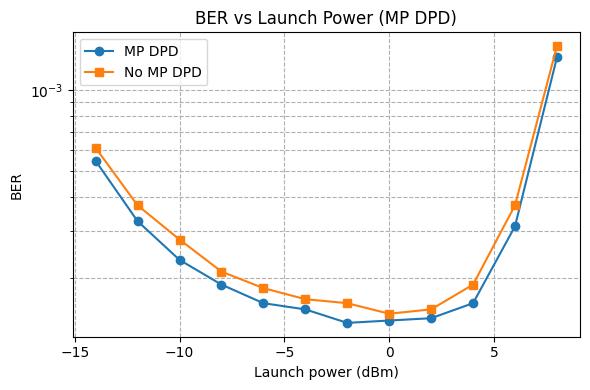

In [63]:
import matplotlib.pyplot as plt

# launch power
launch_powers = [r['Launch Power'] for r in results_mp[:12]]
ber_list = [6.083e-04, 3.722e-04, 2.778e-04, 2.111e-04, 1.833e-04, 1.667e-04, 1.611e-04, 1.472e-04, 1.528e-04, 1.889e-04, 3.722e-04, 1.453e-03]

# BER
ber_mp = [r['BER'] for r in results_mp[:12]]

plt.figure(figsize=(6,4))
plt.semilogy(launch_powers, ber_mp, marker='o', linestyle='-', label='MP DPD')
plt.semilogy(launch_powers, ber_list, marker='s', linestyle='-', label ='No MP DPD' )

plt.xlabel('Launch power (dBm)')
plt.ylabel('BER')
plt.title('BER vs Launch Power (MP DPD)')
plt.grid(True, which='both', linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()
